# Forecasting South Korean Monthly Total Exports

**NUS Investment Society - Quantitative Research Department Application (AY 26/27)** 
**Case Q1: "Develop a model to forecast South Korea's monthly Total Exports"**

---

## 1. Introduction

### 1.1 Objective

To develop a model of **South Korea's own monthly total exports**

### 1.2 Data source

The model uses data from **FRED series `VALEXPKRM052N`**, the value of goods exported 
by the Republic of Korea, monthly, in millions of USD. The data is compiled by the **IMF's 
International Financial Statistics** and redistributed by the Federal Reserve Bank of St. Louis
(FRED). It runs from **January 2006 to May 2026**, with 245 monthly observations.

Importantly, the series is **not seasonally adjusted (NSA)**. The chosen models (Holt-Winters and 
SARIMA) explicitly model seasonality, so working with the raw data avoids double-handling seasonality.

One important caveat is that I did not include data about exported services, as there is no publicly
available NSA data for both goods and services.

### 1.3 Roadmap

1. Load FRED export series.
2. Exploratory Data analysis: analysing trends, cycles, seasonality and stationarity.
3. Model specifications: inspired by a published study on SARIMA vs Holt-Winters models for forecasting exports.
4. 42-month **walk-forward** out-of-sample evaluation.
5. Findings, residual diagnostics, takeaways and evaluation.

In [129]:
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

## 2. Data Preparation

FRED's export is a two-column CSV (`observation_date`, series value). With one row per month.

In [130]:

RAW_PATH = "exports_korea_raw.csv"

raw = pd.read_csv(RAW_PATH, parse_dates=["observation_date"]).dropna()
s = raw.set_index("observation_date")["VALEXPKRM052N"].astype(float).sort_index()
s.index.freq = "MS"
s.name = "exports"

# check for gaps and missing values
full_range = pd.date_range(s.index.min(), s.index.max(), freq="MS")
assert full_range.difference(s.index).empty, "gap detected in monthly series"
assert s.isna().sum() == 0, "missing values detected"

print(f"Loaded {len(s)} monthly observations: {s.index[0].date()} to {s.index[-1].date()}")
print(f"Units: USD millions, NSA (source: IMF IFS via FRED)")
s.tail()


Loaded 245 monthly observations: 2006-01-01 to 2026-05-01
Units: USD millions, NSA (source: IMF IFS via FRED)


observation_date
2026-01-01   65,835.00
2026-02-01   67,654.00
2026-03-01   87,321.00
2026-04-01   85,830.00
2026-05-01   87,821.00
Freq: MS, Name: exports, dtype: float64

## 3. Exploratory Data Analysis

### 3.1 Full History: Cyclical Growth and an Ongoing Structural Shock

Korea's total exports are a well-studied macro series. Plotting the full 2006–2026 history and 12-month rolling mean show distinct episodes:

- **2008–09 Global Financial Crisis** — exports fell from USD 36.6bn (Aug-2008) to ~USD 21.1bn (Jan-2009).
- **2014–16 slowdown** — from USD 49.7bn (Dec-2014) to USD 35.9bn (Feb-2016), associated with the semiconductor industry's downturn.
- **2018–19 stagnation** — from USD 54.9bn (Oct-2018) to USD 44.0bn (Aug-2019), coinciding with US-China trade tensions.
- **2020 COVID-19 shock** — from USD 43.1bn (Jan-2020) down to USD 34.9bn (May-2020).
- **2021–22 post-pandemic/semiconductor surge** — a strong recovery.
- **2023 correction** — from USD 63.8bn (Mar-2022) down to USD 52.0bn (Aug-2023), following the global tech market's downturn.

Most striking of all, the last three months of the sample (March–May 2026) show a sharp increase: the 12-month rolling mean rose from about USD 60.5bn (Jan-2026) to about USD 69.1bn (May-2026), and single-month exports jumped from USD 67.7bn (Feb-2026) to USD 87.3bn (Mar-2026). This sharp rise is well-documented and attributed to the surge in semiconductor exports, following rising demand and prices for memory chips caused by investment in Artificial Intelligence. In May-2026, semiconductor exports accounted for over 40% of total exports, surging 169% above the previous year.

This event is flagged because it affects the evaluation of the out-of-sample results in Part 5.

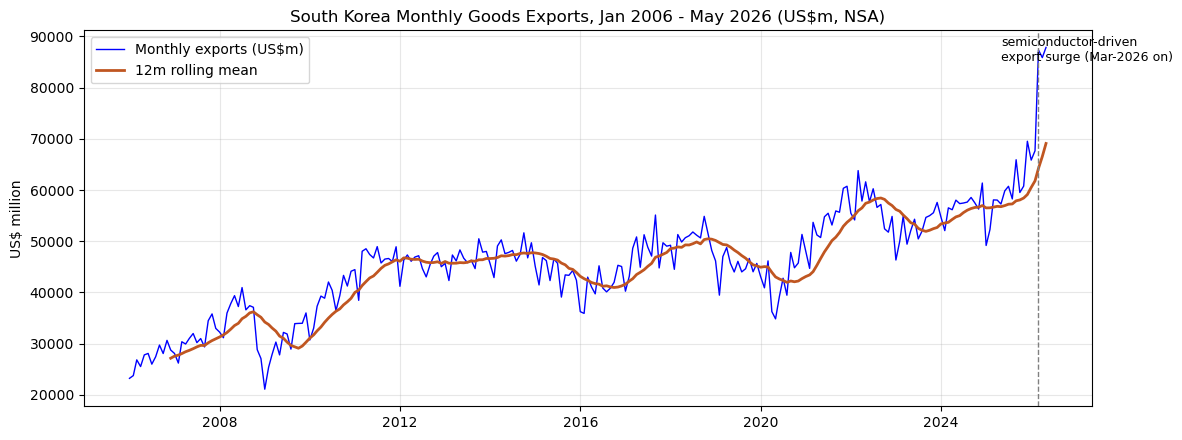

In [131]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(s.index, s.values, lw=1, color="blue", label="Monthly exports (US$m)")
ax.plot(s.index, s.rolling(12).mean(), lw=2, color="#c05621", label="12m rolling mean")
ax.axvline(pd.Timestamp("2026-03-01"), color="grey", ls="--", lw=1)
ax.text(pd.Timestamp("2025-05-01"), s.max() * 0.97, "semiconductor-driven\nexport surge (Mar-2026 on)",
        fontsize=9, color="black")
ax.set_title("South Korea Monthly Goods Exports, Jan 2006 - May 2026 (US$m, NSA)")
ax.set_ylabel("US$ million")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


### 3.2 Log transform

For typical trade-value series, the typical swings scale with the current level (multiplicatively, not additively),
we model the natural log of the series to stabilise the variance across 2006-2026.

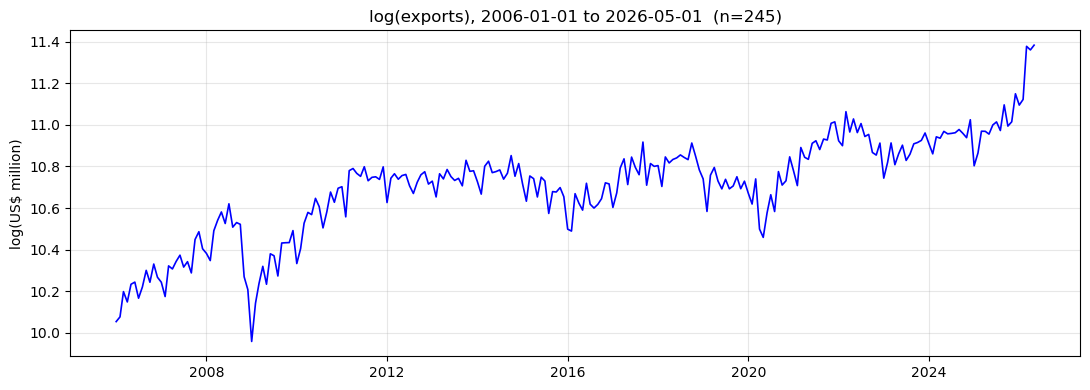

In [132]:
log_s = np.log(s)

fig, ax = plt.subplots()
ax.plot(log_s.index, log_s.values, lw=1.2, color="blue")
ax.set_title(f"log(exports), {s.index[0].date()} to {s.index[-1].date()}  (n={len(s)})")
ax.set_ylabel("log(US$ million)")
plt.tight_layout()
plt.show()


### 3.3 Reserving the walk-forward test-window

The following diagnostics are computed purely on the pre-test training window, following the same split as Section 5's walk-forward evaluation. None of the exploratory statistics should be informed by data the model is later evaluated against. 

In [133]:
N_OOS = 42  # walk-forward horizon
n = len(s)
train_level = s.iloc[: n - N_OOS]
train_init = log_s.iloc[: n - N_OOS]
print(f"Diagnostics below use the pre-test training window only: "
      f"{train_init.index[0].date()} to {train_init.index[-1].date()} ({len(train_init)} months)")
print(f"Reserved walk-forward test window: "
      f"{s.index[n - N_OOS].date()} to {s.index[-1].date()} ({N_OOS} months)")

Diagnostics below use the pre-test training window only: 2006-01-01 to 2022-11-01 (203 months)
Reserved walk-forward test window: 2022-12-01 to 2026-05-01 (42 months)


### 3.4 Seasonal-trend decomposition

We use STL (Seasonal-Trend decomposition using Loess) on the log series, using the following definitions of
seasonal and trend strength:

$$F_S = \max\left(0,\ 1 - \frac{\mathrm{Var}(R)}{\mathrm{Var}(S+R)}\right), \qquad
F_T = \max\left(0,\ 1 - \frac{\mathrm{Var}(R)}{\mathrm{Var}(T+R)}\right)$$


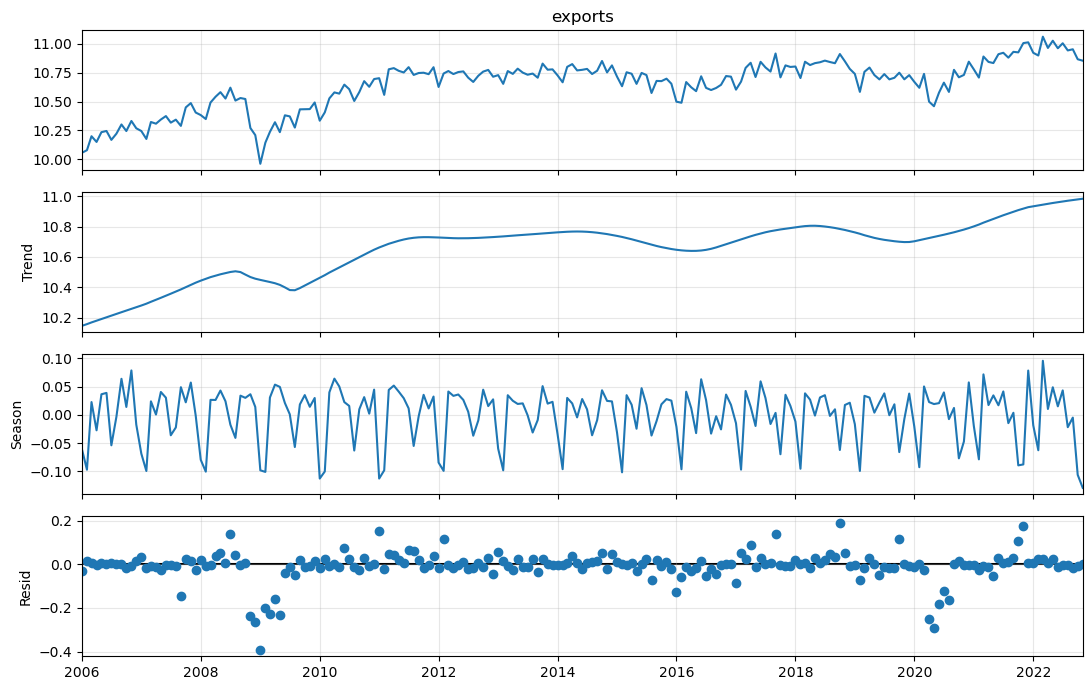

Seasonal strength: 0.261   Trend strength: 0.893

Average detrended log-deviation by month:


observation_date
1    -0.07
2    -0.10
3     0.03
4     0.01
5    -0.01
6     0.02
7     0.01
8    -0.04
9     0.01
10    0.02
11    0.01
12    0.01
dtype: float64

In [134]:
stl = STL(train_init, period=12, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(11, 7)
plt.tight_layout()
plt.show()

seasonal_strength = max(0, 1 - stl.resid.var() / (stl.seasonal + stl.resid).var())
trend_strength = max(0, 1 - stl.resid.var() / (stl.trend + stl.resid).var())
print(f"Seasonal strength: {seasonal_strength:.3f}   Trend strength: {trend_strength:.3f}")

detrended = train_init - stl.trend
monthly_avg = detrended.groupby(detrended.index.month).mean()
print("\nAverage detrended log-deviation by month:")
monthly_avg.round(3)

Trend strength is very high (0.893), reflecting the strong multi-year growth and cycles seen in section 3.1.
The seasonal strength is moderate (0.261). 

Averaging the detrended log series by calendar months shows a clear pattern: January and February are the weakest months (log deviations -0.07 and -0.10, respectively), and March consistently rebounds (+0.03). This follows the well-documented Lunar New Year effect on Korean (and East Asian) trade statistics. The holiday falls in January or February every year, and factories and shipping schedules slow down around this time, with activity picking back up in the following months.

### 3.5 Stationarity 

A stationary time series is one whose mean, variance and autocorrelation remain unchanged over time. We perform an **Augmented Dickey-Fuller test (ADF)** and a **Kwiatkowski–Phillips–Schmidt–Shin test (KPSS)** to confirm the stationarity of the time series. In the SARIMA model below, the AR and MA terms only describe a stationary series. This requires us to difference the time series by d (non-seasonal) and D (seasonal). We then perform the ADF and KPSS tests on the differenced series to confirm whether the transformation applied is sufficient to consider the series stationary.

In [135]:
def report_stationarity(x, label):
    adf_stat, adf_p, *_ = adfuller(x, autolag="AIC")
    kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")
    print(f"{label:38s} ADF p={adf_p:6.4f} (H0: unit root (non-stationary))    KPSS p={kpss_p:6.4f} (H0: stationary)")

report_stationarity(train_level, "Level (exports, US$m)")
report_stationarity(train_init, "Log level")
report_stationarity(train_init.diff().dropna(), "Log, 1st difference")
report_stationarity(train_init.diff().diff(12).dropna(), "Log, 1st diff + seasonal diff(12)")
print()
print("KPSS\'s p-value comes from interpolating a fixed lookup table of critical values \
(Kwiatkowski et al.,1992) and only covers 0.01–0.10. Any KPSS statistic outside that range \
is reported at the nearest boundary rather than an exact value")

Level (exports, US$m)                  ADF p=0.1443 (H0: unit root (non-stationary))    KPSS p=0.0100 (H0: stationary)
Log level                              ADF p=0.1270 (H0: unit root (non-stationary))    KPSS p=0.0100 (H0: stationary)
Log, 1st difference                    ADF p=0.0010 (H0: unit root (non-stationary))    KPSS p=0.1000 (H0: stationary)
Log, 1st diff + seasonal diff(12)      ADF p=0.0000 (H0: unit root (non-stationary))    KPSS p=0.1000 (H0: stationary)

KPSS's p-value comes from interpolating a fixed lookup table of critical values (Kwiatkowski et al.,1992) and only covers 0.01–0.10. Any KPSS statistic outside that range is reported at the nearest boundary rather than an exact value


Both the level and log(level) series are non-stationary. ADF fails to reject a unit-root and KPSS rejects stationarity. 
A series with a single non-seasonal difference and one with non-seasonal difference and seasonal difference are considered stationary. ADF rejects the unit-root and KPSS fails to reject stationarity. 

### 3.6 Autocorrelation function and Partial Autocorrelation function

The Autocorrelation function (ACF) measure the correlation of a series with a lagged copy of itself at each lag `k`. 
The Partial Autocorrelation function (PACF) measures the same correlation but isolates the direct correlation at lag `k`, ignoring the data points in the series between them. 

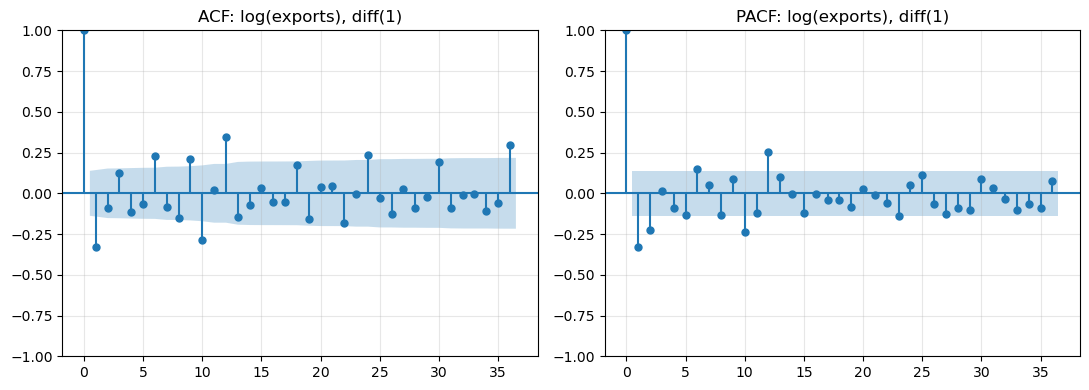

In [136]:
dd = train_init.diff().dropna()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_acf(dd, lags=36, ax=axes[0])
plot_pacf(dd, lags=36, ax=axes[1], method="ywm")
axes[0].set_title("ACF: log(exports), diff(1)")
axes[1].set_title("PACF: log(exports), diff(1)")
plt.tight_layout()
plt.show()

Reading the plots against the $\pm 1.96/\sqrt{n}$ significance band: **lag 1 clears the band on both the ACF and PACF**, representing a short run structure, not noise; **lag 12 clears both too**, confirming a real seasonal signal, consistent with the Lunar New Year pattern. Lag 24's ACF is significant but not its PACF, showing that the lag 12 propagates to lag 24 in ACF. This visual is merely a rough hypothesis; the AIC/BIC grid search below gives a more rigorous idea of the SARIMA model we use. 

## 4. Model Specification

### 4.1 Research inspiration and benchmark

As a methodological reference, we follow **Hasibuan, Musthofa, Putri & Jannah (2023), "Comparison of Seasonal Time Series Forecasting using SARIMA and Holt-Winters Exponential Smoothing"**, which studies the forecasting of seasonal export series too. The authors compared a SARIMA model against Holt-Winters exponential smoothing and reported SARIMA as the more accurate of the two (MAPE 0.44% vs 0.89%). 

Following this template, we compare the following 4 models, listed in increasing complexity:

1. **Seasonal Naive**: forecasts each month with the same data point from the same month a year ago.
2. **Holt-Winters exponential smoothing**: modelling the series as additive trend + additive seasonal
3. **SARIMA, primary**: Akaike Information Criterion (AIC)/Bayesian Information Criterion (BIC) selects order
4. **SARIMA, alt.**: next best distinct specification found by AIC/BIC

### 4.2 Order selection

SARIMA orders are chosen using a grid search ($p,q \in \{0,1,2\}$, $d\in\{0,1\}$, $P, Q\in\{0,1\}$, $D\in\{0,1\}$, seasonal period 12) minimising AIC/BIC, a score used to measure model quality, using training-window data. This order is then held fixed for the walk-forward exercise below. 

In [137]:
print(f"Order-selection window: {train_init.index[0].date()} to {train_init.index[-1].date()} "
      f"(n={len(train_init)})")
print(f"Walk-forward window:    {s.index[n - N_OOS].date()} to {s.index[-1].date()} ({N_OOS} months)")

p = d = q = range(0, 3)
P = D = Q = range(0, 2)
season = 12

results = []
for (pi, di, qi) in itertools.product(p, d, q):
    for (Pi, Di, Qi) in itertools.product(P, D, Q):
        if pi + qi + Pi + Qi == 0:
            continue
        try:
            fit = sm.tsa.statespace.SARIMAX(
                train_init, order=(pi, di, qi), seasonal_order=(Pi, Di, Qi, season),
                enforce_stationarity=False, enforce_invertibility=False,
            ).fit(disp=False)
            results.append({"order": (pi, di, qi), "seasonal_order": (Pi, Di, Qi, season),
                             "AIC": fit.aic, "BIC": fit.bic})
        except Exception:
            continue
grid = pd.DataFrame(results)
print("Top 5 by AIC:")
print(grid.sort_values("AIC").head(5).to_string(index=False))
print("\nTop 5 by BIC:")
print(grid.sort_values("BIC").head(5).to_string(index=False))

Order-selection window: 2006-01-01 to 2022-11-01 (n=203)
Walk-forward window:    2022-12-01 to 2026-05-01 (42 months)
Top 5 by AIC:
    order seasonal_order     AIC     BIC
(1, 1, 0)  (1, 0, 1, 12) -465.61 -452.65
(2, 0, 0)  (1, 0, 1, 12) -463.97 -447.77
(2, 0, 1)  (1, 0, 1, 12) -462.91 -443.46
(1, 0, 2)  (1, 0, 1, 12) -462.41 -443.00
(2, 1, 0)  (1, 0, 1, 12) -462.10 -445.92

Top 5 by BIC:
    order seasonal_order     AIC     BIC
(1, 1, 0)  (1, 0, 1, 12) -465.61 -452.65
(2, 0, 0)  (1, 0, 1, 12) -463.97 -447.77
(0, 1, 1)  (1, 0, 1, 12) -458.89 -445.94
(2, 1, 0)  (1, 0, 1, 12) -462.10 -445.92
(1, 1, 1)  (1, 0, 1, 12) -461.56 -445.38


From the top 5 ranked models above, both AIC and BIC agree on the top 2 most accurate model specifications. Rank 1 is
**SARIMA(1,1,0)(1,0,1)₁₂**, and rank 2 is **SARIMA(2,0,0)(1,0,1)₁₂**.

## 5. Rolling Walk-Forward Out-of-Sample Evaluation

For each of the last 42 months of data, every model is refitted using **all data available up to that point** and produces a single forecast for the next month in the series. 

In [138]:
origins = range(n - N_OOS, n)
records = []

ORDER_PRIMARY, SORDER_PRIMARY = (1, 1, 0), (1, 0, 1, 12)
ORDER_ALT, SORDER_ALT = (2, 0, 0), (1, 0, 1, 12)

for t in origins:
    train_level = s.iloc[:t]
    train_log = log_s.iloc[:t]
    actual = s.iloc[t]
    date = s.index[t]

    # 1. Seasonal naive
    f_naive = train_level.iloc[-12]

    # 2. Holt-Winters (additive trend + additive seasonal), fit on the level series
    try:
        hw = ExponentialSmoothing(
            train_level, trend="add", seasonal="add", seasonal_periods=12,
            initialization_method="estimated",
        ).fit(optimized=True)
        f_hw = hw.forecast(1).iloc[0]
    except Exception:
        f_hw = np.nan

    # 3. SARIMA primary
    try:
        m1 = sm.tsa.statespace.SARIMAX(
            train_log, order=ORDER_PRIMARY, seasonal_order=SORDER_PRIMARY,
            enforce_stationarity=False, enforce_invertibility=False,
        ).fit(disp=False)
        f_sarima_primary = float(np.exp(m1.forecast(1).iloc[0]))
    except Exception:
        f_sarima_primary = np.nan

    # 4. SARIMA alt
    try:
        m2 = sm.tsa.statespace.SARIMAX(
            train_log, order=ORDER_ALT, seasonal_order=SORDER_ALT,
            enforce_stationarity=False, enforce_invertibility=False,
        ).fit(disp=False)
        f_sarima_alt = float(np.exp(m2.forecast(1).iloc[0]))
    except Exception:
        f_sarima_alt = np.nan

    records.append({"date": date, "actual": actual, "seasonal_naive": f_naive,
                     "holt_winters": f_hw, "sarima_primary": f_sarima_primary,
                     "sarima_alt": f_sarima_alt})

res = pd.DataFrame(records).set_index("date")
print(f"Walk-forward complete: {len(res)} out-of-sample months "
      f"({res.index[0].date()} to {res.index[-1].date()})")
res.tail()

Walk-forward complete: 42 out-of-sample months (2022-12-01 to 2026-05-01)


,actual,seasonal_naive,holt_winters,sarima_primary,sarima_alt
date,,,,,
2026-01-01,"65,835.00","49,177.00","61,215.40","61,124.93","61,020.50"
2026-02-01,"67,654.00","52,292.00","62,945.05","64,448.31","64,408.06"
2026-03-01,"87,321.00","58,065.00","71,456.92","73,025.84","73,025.48"
2026-04-01,"85,830.00","58,036.00","78,890.40","79,345.65","79,435.18"
2026-05-01,"87,821.00","57,261.00","84,129.79","85,223.02","85,412.44"


We evaluate the accuracy of the forecasting models using MAE (Mean Absolute Error), RMSE (Root Mean Squared Error), and MAPE (Mean Absolute Percentage Error).

In [139]:
def mae(a, f):  return np.mean(np.abs(a - f))
def rmse(a, f): return np.sqrt(np.mean((a - f) ** 2))
def mape(a, f): return np.mean(np.abs((a - f) / a)) * 100

model_cols = ["seasonal_naive", "holt_winters", "sarima_primary", "sarima_alt"]
metrics_df = pd.DataFrame([
    {"model": m, "MAE": mae(res["actual"], res[m]), "RMSE": rmse(res["actual"], res[m]),
     "MAPE_%": mape(res["actual"], res[m])}
    for m in model_cols
]).set_index("model")

metrics_df.round(2)

,MAE,RMSE,MAPE_%
model,,,
seasonal_naive,"6,778.93","9,878.34",10.66
holt_winters,"2,573.52","3,769.43",4.13
sarima_primary,"2,735.10","3,744.37",4.48
sarima_alt,"2,785.12","3,771.86",4.57


## 6. Findings

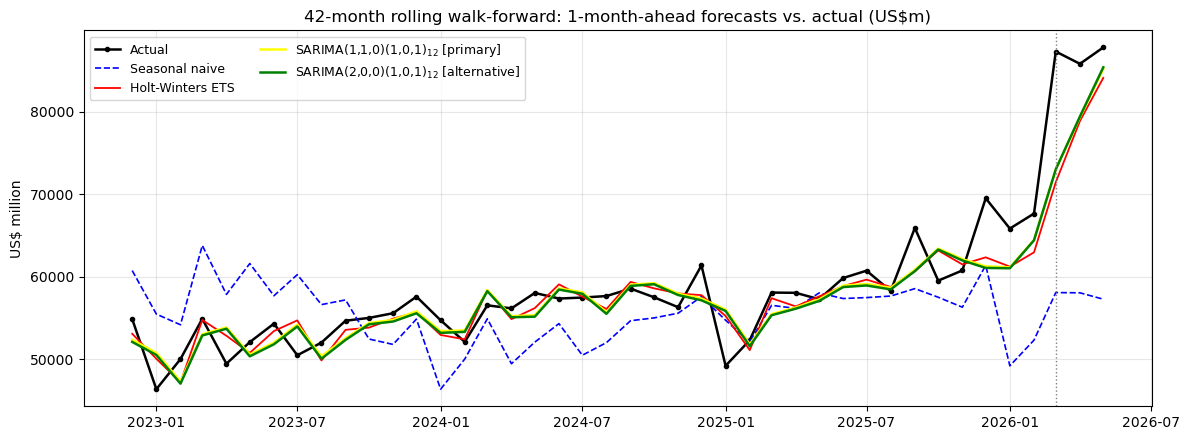

In [140]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(res.index, res["actual"], color="black", lw=1.8, marker="o", ms=3, label="Actual")
ax.plot(res.index, res["seasonal_naive"], color="blue", lw=1.2, ls="--", label="Seasonal naive")
ax.plot(res.index, res["holt_winters"], color="red", lw=1.3, label="Holt-Winters ETS")
ax.plot(res.index, res["sarima_primary"], color="yellow", lw=1.8,
        label="SARIMA(1,1,0)(1,0,1)$_{12}$ [primary]")
ax.plot(res.index, res["sarima_alt"], color="green", lw=1.8,
        label="SARIMA(2,0,0)(1,0,1)$_{12}$ [alternative]")
ax.axvline(pd.Timestamp("2026-03-01"), color="grey", ls=":", lw=1)
ax.set_title("42-month rolling walk-forward: 1-month-ahead forecasts vs. actual (US$m)")
ax.set_ylabel("US$ million")
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

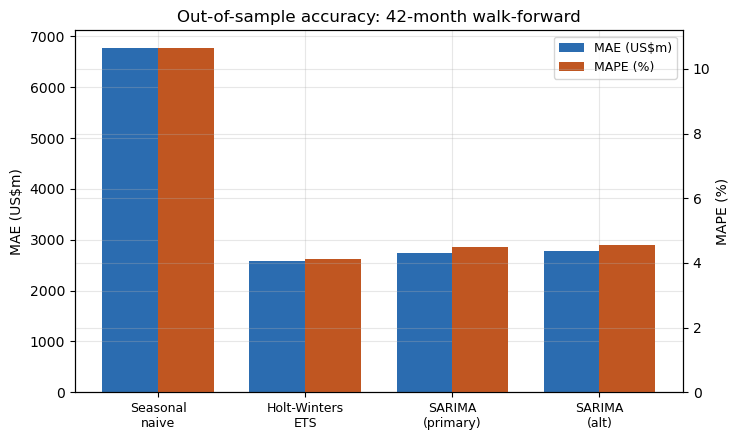

In [141]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
labels = ["Seasonal\nnaive", "Holt-Winters\nETS", "SARIMA\n(primary)", "SARIMA\n(alt)"]
x = np.arange(len(labels))
width = 0.38
ax.bar(x - width/2, metrics_df.loc[model_cols, "MAE"], width, label="MAE (US$m)", color="#2b6cb0")
ax2 = ax.twinx()
ax2.bar(x + width/2, metrics_df.loc[model_cols, "MAPE_%"], width, label="MAPE (%)", color="#c05621")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("MAE (US$m)"); ax2.set_ylabel("MAPE (%)")
l1, lb1 = ax.get_legend_handles_labels(); l2, lb2 = ax2.get_legend_handles_labels()
ax.legend(l1 + l2, lb1 + lb2, loc="upper right", fontsize=9)
ax.set_title("Out-of-sample accuracy: 42-month walk-forward")
plt.tight_layout()
plt.show()

In [143]:
res_ex = res.iloc[:-3]  # excluding Mar-May 2026
metrics_ex = pd.DataFrame([
    {"model": m, "MAE": mae(res_ex["actual"], res_ex[m]), "RMSE": rmse(res_ex["actual"], res_ex[m]),
     "MAPE_%": mape(res_ex["actual"], res_ex[m])}
    for m in model_cols
]).set_index("model")
print("Accuracy EXCLUDING the last 3 months (Mar-May 2026 export surge):")
metrics_ex.round(2)

Accuracy EXCLUDING the last 3 months (Mar-May 2026 export surge):


,MAE,RMSE,MAPE_%
model,,,
seasonal_naive,"5,053.97","6,275.92",8.90
holt_winters,"2,092.12","2,695.25",3.67
sarima_primary,"2,346.07","2,933.91",4.14
sarima_alt,"2,407.08","2,980.59",4.24


### 6.1 Reading the results

- All three models comfortably beat the seasonal-naive baseline over the 42-month test window (MAE ≈ US\$2.5–2.8bn vs. US\$6.8bn; MAPE ≈ 4.1–4.6% vs. 10.7%)
- **Holt-Winters and the primary SARIMA both perform well**. Holt-Winters has a lower MAE (US\$2,574m vs. US\$2,735m), while primary SARIMA has a lower RMSE (US\$3,744m vs. US\$3,769m). In MAPE %, Holt-Winters outperforms SARIMA (4.13% vs 4.48%).
- **The alt SARIMA underperforms relative to the primary SARIMA**. (MAE US\$2,785m, RMSE US\$3,772m, MAPE 4.57%). The extra complexity of the alternative does not help the model perform better.
- When we exclude the final 3 months (the anomalous semiconductor export surge), **the model's error drops significantly**. seasonal-naive MAPE falls from 10.66% to 8.90%, Holt-Winters from 4.13% to 3.67%, primary SARIMA from 4.48% to 4.14%. Thus, showing how walk-forward error can be attributable to a single unforecasted shock. 

### 6.2 SARIMA residual diagnostics

In [144]:
final_fit = sm.tsa.statespace.SARIMAX(
    log_s, order=ORDER_PRIMARY, seasonal_order=SORDER_PRIMARY,
    enforce_stationarity=False, enforce_invertibility=False,
).fit(disp=False)
print(final_fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                              exports   No. Observations:                  245
Model:             SARIMAX(1, 1, 0)x(1, 0, [1], 12)   Log Likelihood                 296.723
Date:                              Tue, 18 Aug 2026   AIC                           -585.445
Time:                                      21:49:28   BIC                           -571.676
Sample:                                  01-01-2006   HQIC                          -579.892
                                       - 05-01-2026                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4170      0.055     -7.550      0.000      -0.525      -0.309
ar.S.L12       0.97

In [145]:
resid = final_fit.resid.iloc[1:]
k_sarima = 1 + 0 + 1 + 1  # p+q+P+Q for SARIMA(1,1,0)(1,0,1,12)
lb_naive = acorr_ljungbox(resid, lags=[12, 24], model_df=k_sarima, return_df=True)
print(f"Ljung-Box on ALL residuals, DoF-adjusted for {k_sarima} estimated AR/MA "
      f"parameters (H0: no autocorrelation remaining):")
print(lb_naive.to_string(float_format=lambda x: f"{x:.3f}"))
print("\nLargest-magnitude residuals:")
print(resid.abs().sort_values(ascending=False).head(6))

Ljung-Box on ALL residuals, DoF-adjusted for 3 estimated AR/MA parameters (H0: no autocorrelation remaining):
    lb_stat  lb_pvalue
12   47.867      0.000
24   49.809      0.000

Largest-magnitude residuals:
observation_date
2007-01-01   4.53
2006-02-01   2.12
2007-02-01   1.40
2008-11-01   0.34
2020-04-01   0.24
2009-01-01   0.22
dtype: float64


At first glance, for both 12 and 24 lags, the primary SARIMA model fails the Ljung-Box test, adjusted for the model's 3 degrees-of-freedom for the model. However, further analysis of the data reveals that the largest-magnitude residuals occur in the first year of the sample (Jan 2007, Feb 2006, Feb 2007). This is likely a consequence of diffuse state-space initialisation: The model begins with high initial uncertainty. The model roughly needs a full seasonal cycle of data before its state uncertainty has collapsed. We re-run the test, now excluding the first 13 months of data (one seasonal cycle + initial differenced observation).

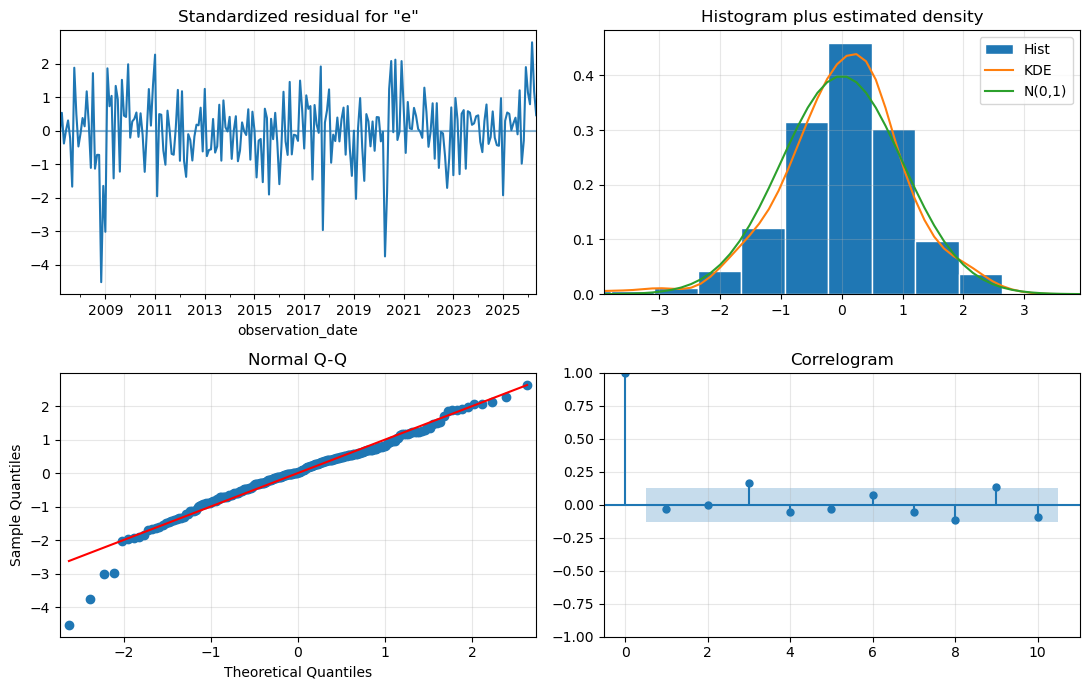

Ljung-Box excluding the first 13 months (from 2007-02-01 onward, n=232), DoF-adjusted for 3 parameters:
    lb_stat  lb_pvalue
12    5.883      0.752
24   20.494      0.490


In [146]:
resid_trimmed = final_fit.resid.iloc[13:]
lb_trimmed = acorr_ljungbox(resid_trimmed, lags=[12, 24], model_df=k_sarima, return_df=True)

fig = final_fit.plot_diagnostics(figsize=(11, 7))
plt.tight_layout()
plt.show()

print(f"Ljung-Box excluding the first 13 months (from {resid_trimmed.index[0].date()} "
      f"onward, n={len(resid_trimmed)}), DoF-adjusted for {k_sarima} parameters:")
print(lb_trimmed.to_string(float_format=lambda x: f"{x:.3f}"))

After excluding the warm-up window, the Ljung-Box test passes at both lags (p ≈ 0.752 and p ≈ 0.490). There is no detectable autorcorrelation in the model's residuals. In the diagnostics plots above, we visualise the outliers in the data, corresponding to the 2008 GFC and 2026 semiconductor surge.

### 6.3 Holt-Winters residual diagnostics

The same Ljung-Box test is applied on the Holt-Winters model, degrees-of-freedom adjusted for its three smoothing parameters (α, β, γ).

In [147]:
hw_final = ExponentialSmoothing(
    s, trend="add", seasonal="add", seasonal_periods=12,
    initialization_method="estimated",
).fit(optimized=True)
resid_hw = hw_final.resid
k_hw = 3  # alpha, beta, gamma

lb_hw = acorr_ljungbox(resid_hw, lags=[12, 24], model_df=k_hw, return_df=True)
print(f"Ljung-Box on ALL Holt-Winters residuals, DoF-adjusted for {k_hw} smoothing parameters:")
print(lb_hw.to_string(float_format=lambda x: f"{x:.3f}"))

lb_hw_trimmed = acorr_ljungbox(resid_hw.iloc[13:], lags=[12, 24], model_df=k_hw, return_df=True)
print(f"\nLjung-Box excluding the first 13 months, DoF-adjusted:")
print(lb_hw_trimmed.to_string(float_format=lambda x: f"{x:.3f}"))

print("\nLargest-magnitude residuals:")
print(resid_hw.abs().sort_values(ascending=False).head(6))

Ljung-Box on ALL Holt-Winters residuals, DoF-adjusted for 3 smoothing parameters:
    lb_stat  lb_pvalue
12   25.404      0.003
24   37.325      0.015

Ljung-Box excluding the first 13 months, DoF-adjusted:
    lb_stat  lb_pvalue
12   24.121      0.004
24   32.991      0.046

Largest-magnitude residuals:
observation_date
2026-03-01   15,160.54
2020-04-01   10,424.17
2017-10-01   10,166.05
2008-11-01    8,319.66
2025-12-01    7,230.84
2020-12-01    6,325.89
dtype: float64


Unlike SARIMA, Holt-Winters fails Ljung-Box at both lags on the full residual series (p < 0.05). Importantly, this is not fully resolved by applying the same first 13-months trim (p ≈ 0.004 and p ≈ 0.046). The largest Holt-Winters residuals are explainable by real macro events (2026 semiconductor surge, COVID, GFC), but the Ljung-Box test flags residual autocorrelation as statistically significant. 

Comparing residual tests for SARIMA and Holt-Winters, SARIMA's residuals are cleaner, in spite of Holt-Winters' better forecast accuracy.

## 7. Key Takeaways

- **SARIMA(1,1,0)(1,0,1)₁₂ is the best model in this comparison** — not Holt-Winters. The two models are nearly tied on raw accuracy. Holt-Winters performs better based on MAE (2,574 vs 2,735), SARIMA outperforms on RMSE (3,744 vs 3,769). SARIMA differentiates itself as its residuals pass a Ljung-Box test (p≈0.75, p≈0.49), while Holt-Winters' do not (p≈0.004, p≈0.046).
- The order of the SARIMA model is **agreed on by both AIC and BIC** using only pre-walk-forward training data. The model is re-fit at every step of a 42-month expanding-window walk-forward.
- Korea's total exports have a strong trend strength (≈0.89) and moderate seasonality (≈0.26; the Lunar New Year effect depressing January/February and boosting March).
- A different, more complex specification (the next-best distinct AIC
  candidate, SARIMA(2,0,0)(1,0,1)₁₂) does not improve out-of-sample accuracy and performs worse in MAE, RMSE and MAPE.
- The semiconductor investment driven export boom in March–May 2026 (exports up 48%+ year-on-year in March, semiconductor exports up over 150%) significantly inflates every model's out-of-sample error in the final months of the walk-forward window. By excluding those three months, every model's accuracy improves. 
- SARIMA's Ljung-Box failure at face value is fully attributable to diffuse
  state-space initialisation warm-up.By excluding that warm-up window, it passes cleanly at both 12 and 24 lags.
- Holt-Winters' Ljung-Box failure does **not** resolve the same way. The leftover residual structure is a genuine specification gap, the deciding
  factor behind picking SARIMA as the better model overall.

## 8. Limitations & Future Work

- **Not seasonally adjusted.** The series is NSA by design, which is
  appropriate as the model handles seasonality, but it does mean
  raw month-to-month comparisons are more volatile than a SA source.
- **Univariate only.** No exogenous regressors were used. However, since Korea's exports are dominated by semiconductors, a SARIMAX with global semiconductor price indices, the KRW effective exchange rate, or global manufacturing PMI as regressors could possibly have helped anticipate the 2026 surge, and is a natural follow-up to the model.
- **Sensitivity to demand shocks.** The model's out of sample error is significantly inflated by the last 3 months of the sample. The accuracy figures should be read as a conditional of this particular test window, not a fixed property of the model. 